In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

In [2]:
# Loading dataset
(train_images, train_labels), (test_images, test_labels) = tf.keras.datasets.mnist.load_data()

In [3]:
print("Train Images Shape: ", train_images.shape)
print("Train Labels Shape: ", train_labels.shape)
print("Test Images Shape: ", test_images.shape)
print("Test Labels Shape: ", test_labels.shape)

Train Images Shape:  (60000, 28, 28)
Train Labels Shape:  (60000,)
Test Images Shape:  (10000, 28, 28)
Test Labels Shape:  (10000,)


In [4]:
#Normalization
train_images = train_images / 255.0
test_images = test_images / 255.0

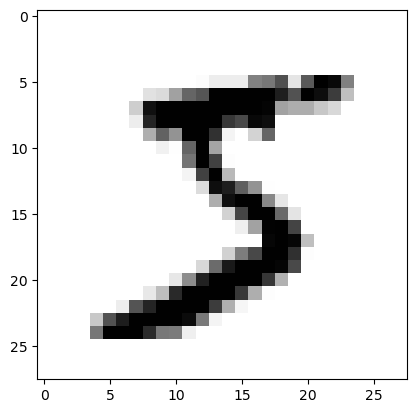

This is an image for:  5


In [5]:
# plt.figure()
plt.imshow(train_images[0], cmap=plt.cm.binary) #cmap makes the plot in black and white only
plt.grid(False)
plt.show()
print("This is an image for: ", train_labels[0])
#print(train_images[0])

In [7]:
 #its like making hidden layers and each hidden layer contains number of neurons(128)
model = models.Sequential([
    layers.Flatten(input_shape=(28, 28)),
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])
#the last layer is like the output after recognizing the features
# You can also drop out layers
#softmax
#sigmoid

In [8]:
# its some kind of optimization
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [15]:
# training the model
model.fit(train_images, train_labels, epochs=5) 
#epochs = number of iterations -> if 1 the model will not learn
#                              -> if too large overfitting will occur

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9977 - loss: 0.0073
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9984 - loss: 0.0053
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9982 - loss: 0.0066
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9984 - loss: 0.0055
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9973 - loss: 0.0092


In [16]:
# model evaluation
test_loss, test_acc = model.evaluate(test_images, test_labels, verbose=2) #To show the loading bar
print("Test Accuracy: ", test_acc)

313/313 - 0s - 799us/step - accuracy: 0.9777 - loss: 0.1923
Test Accuracy:  0.9776999950408936


In [17]:
predictions = model.predict(test_images)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 913us/step


Predicted Label:  0
True Label:  0


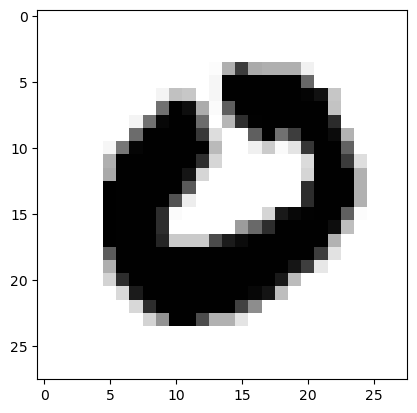

In [21]:
print("Predicted Label: ", predictions[25].argmax()) #To get the max probability that the number will be something
print("True Label: ", test_labels[25])
plt.imshow(test_images[25], cmap=plt.cm.binary)
plt.show()

In [ ]:
#Forward Probagation -> The model moves layer by layer from the start to the end
#Backward Probagation -> Moves backward in the neural network and calculates the loss to improve the accuracy by recalculating the weights
#Overfitting -> (Drop out neurons, Regularization)
#Underfitting -> (Adding neurons, Increasing the dataset, Increasing the epochs)